In [47]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

fsm = xr.open_dataset("../data/processed/fsm2_sd_all.nc")
senorge = xr.open_dataset("../data/processed/senorge_all.nc")
snow = xr.open_dataset("../data/processed/snowpack_all.nc")

In [48]:
print("FSM vars:", list(fsm.data_vars))
print("seNorge vars:", list(senorge.data_vars))
print("Snow vars:", list(snow.data_vars))

fsm_sd = fsm["snow_depth"]/10.0
senorge_sd = senorge["snow_depth"] 
snow_sd = snow["HS_mod"]/1000.0

print("FSM2 attrs:", fsm_sd.attrs)
print("seNorge attrs:", senorge_sd.attrs)
print("SNOWPACK attrs:", snow_sd.attrs)

FSM vars: ['snow_depth', 'UTM_Zone_33']
seNorge vars: ['snow_depth', 'projection_info', 'UTM_Zone_33', 'snow_water_equivalent']
Snow vars: ['Qs', 'Ql', 'Qg', 'TSG', 'Qg0', 'Qr', 'dIntEnergySnow', 'meltFreezeEnergySnow', 'ColdContentSnow', 'OLWR', 'ILWR', 'LWR_net', 'RSWR', 'ISWR', 'Qw', 'pAlbedo', 'mAlbedo', 'ISWR_h', 'ISWR_dir', 'ISWR_diff', 'TA', 'TSS_mod', 'TSS_meas', 'T_bottom', 'RH', 'VW', 'VW_drift', 'DW', 'MS_Snow', 'HS_mod', 'HS_meas', 'hoar_size', 'wind_trans24', 'HN3', 'HN6', 'HN12', 'HN24', 'HN72_24', 'HNW24', 'ski_pen', 'SWE', 'MS_Water', 'MS_Water_Soil', 'MS_Ice_Soil', 'MS_Wind', 'MS_Rain', 'MS_SN_Runoff', 'MS_Surface_Mass_Flux', 'MS_Soil_Runoff', 'MS_Sublimation', 'MS_Evap', 'Sclass1', 'Sclass2', 'zSd', 'Sd', 'zSn', 'Sn', 'zSs', 'Ss', 'zS4', 'S4', 'zS5', 'S5']
FSM2 attrs: {'Name': 'snow_depth', 'grid_mapping': 'UTM_Zone_33', 'name': 'snow_depth', 'units': 'mm', 'standard_name': 'snow_depth', 'longname': 'snow depth'}
seNorge attrs: {'grid_mapping': 'projection_info', 'nam

In [49]:
fsm_sd = fsm_sd 
senorge_sd = senorge_sd 
snow_sd = snow_sd.copy()

In [50]:
print("FSM2 min/max [m]:", float(fsm_sd.min()), float(fsm_sd.max()))
print("seNorge min/max [m]:", float(senorge_sd.min()), float(senorge_sd.max()))
print("SNOWPACK min/max [m]:", float(snow_sd.min()), float(snow_sd.max()))

FSM2 min/max [m]: 0.0 1394.0
seNorge min/max [m]: -0.10000000149011612 1487.9000244140625
SNOWPACK min/max [m]: 0.0 0.580604


In [51]:
start = "2024-09-01"
end = "2025-06-01"

fsm_sd = fsm_sd.sel(time=slice(start, end))
senorge_sd = senorge_sd.sel(time=slice(start, end))
snow_sd = snow_sd.sel(time=slice(start, end))

In [52]:
def get_station_series(station_id, snow_ds, fsm_da, senorge_da):
    snow_point = snow_ds.sel(station=station_id)

    x0 = snow_point["x"].item()
    y0 = snow_point["y"].item()

    snow_series = snow_point["HS_mod"]
    fsm_series = fsm_da.sel(x=x0, y=y0, method="nearest")
    senorge_series = senorge_da.sel(x=x0, y=y0, method="nearest")

    return snow_series, fsm_series, senorge_series

In [53]:
station_id = "VIR1000A"

snow_series, fsm_series, senorge_series = get_station_series(
    station_id, snow, fsm_sd, senorge_sd
)

In [54]:
snow_daily = snow_series.resample(time="1D").mean()
fsm_daily = fsm_series
senorge_daily = senorge_series

In [55]:
snow_daily, fsm_daily = xr.align(snow_daily, fsm_daily, join="inner")
snow_daily, senorge_daily = xr.align(snow_daily, senorge_daily, join="inner")

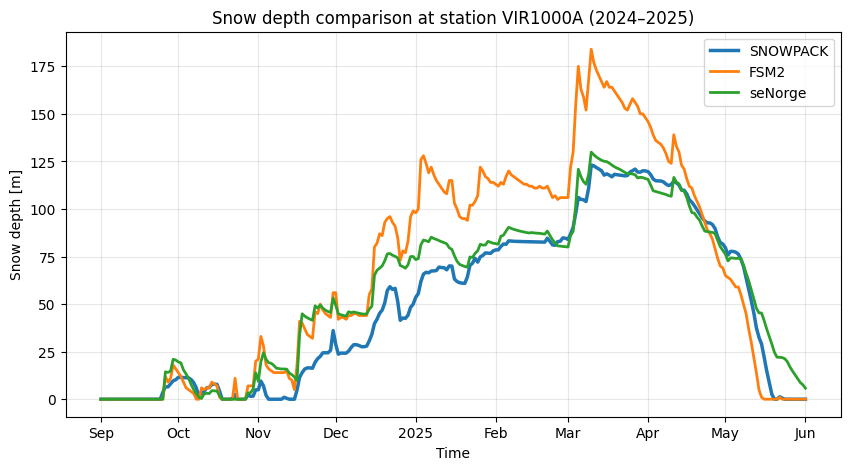

In [56]:
plt.figure(figsize=(10, 5))

snow_daily.plot(label="SNOWPACK", linewidth=2.5)
fsm_daily.plot(label="FSM2", linewidth=2)
senorge_daily.plot(label="seNorge", linewidth=2)

plt.title(f"Snow depth comparison at station {station_id} (2024–2025)")
plt.ylabel("Snow depth [m]")
plt.xlabel("Time")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [57]:
def metrics(model, reference):
    model, reference = xr.align(model, reference, join="inner")

    valid = np.isfinite(model) & np.isfinite(reference)
    model = model.where(valid, drop=True)
    reference = reference.where(valid, drop=True)

    diff = model - reference

    bias = float(diff.mean().values)
    rmse = float(np.sqrt((diff ** 2).mean().values))
    corr = float(xr.corr(model, reference, dim="time").values)

    return bias, rmse, corr

In [58]:
bias_fsm, rmse_fsm, corr_fsm = metrics(fsm_daily, snow_daily)
bias_sen, rmse_sen, corr_sen = metrics(senorge_daily, snow_daily)

print("FSM2 vs SNOWPACK")
print("Bias:", bias_fsm)
print("RMSE:", rmse_fsm)
print("Corr:", corr_fsm)

print("\nseNorge vs SNOWPACK")
print("Bias:", bias_sen)
print("RMSE:", rmse_sen)
print("Corr:", corr_sen)

FSM2 vs SNOWPACK
Bias: 17.746241940389293
RMSE: 27.00195431559463
Corr: 0.950644662937087

seNorge vs SNOWPACK
Bias: 7.4221553118069385
RMSE: 12.163537868771643
Corr: 0.9744868581131076


In [59]:
def compare_station(station_id, snow_sd, fsm_sd, senorge_sd):
    snow_point = snow_sd.sel(station=station_id)

    x0 = float(snow_point["x"].values)
    y0 = float(snow_point["y"].values)

    snow_series = snow_point
    fsm_series = fsm_sd.sel(x=x0, y=y0, method="nearest")
    senorge_series = senorge_sd.sel(x=x0, y=y0, method="nearest")

    # gjør snowpack daglig så den matcher de andre
    snow_daily = snow_series.resample(time="1D").mean()

    # align på tid
    snow_daily, fsm_series = xr.align(snow_daily, fsm_series, join="inner")
    snow_daily, senorge_series = xr.align(snow_daily, senorge_series, join="inner")

    return snow_daily, fsm_series, senorge_series

In [60]:
results = []

station_ids = snow["station"].values

for station_id in station_ids:
    try:
        snow_daily, fsm_series, senorge_series = compare_station(
            station_id, snow_sd, fsm_sd, senorge_sd
        )

        # hopp over stasjoner med for lite data
        if len(snow_daily.time) < 30:
            continue

        bias_fsm, rmse_fsm, corr_fsm = metrics(fsm_series, snow_daily)
        bias_sen, rmse_sen, corr_sen = metrics(senorge_series, snow_daily)

        elev = float(snow["elev"].sel(station=station_id).values)
        lon = float(snow["lon"].sel(station=station_id).values)
        lat = float(snow["lat"].sel(station=station_id).values)

        results.append({
            "station": str(station_id),
            "elev": elev,
            "lon": lon,
            "lat": lat,
            "bias_fsm": bias_fsm,
            "rmse_fsm": rmse_fsm,
            "corr_fsm": corr_fsm,
            "bias_senorge": bias_sen,
            "rmse_senorge": rmse_sen,
            "corr_senorge": corr_sen
        })

    except Exception as e:
        print(f"Feil på {station_id}: {e}")

results_df = pd.DataFrame(results)
results_df.head()

,station,elev,lon,lat,bias_fsm,rmse_fsm,corr_fsm,bias_senorge,rmse_senorge,corr_senorge
0,VIR1A,1410.0,7.427735,61.843654,184.684663,220.190061,0.983633,192.471527,233.402347,0.982387
1,VIR2A,1687.0,7.425528,61.852553,217.394978,252.282186,0.981410,236.828923,276.563542,0.986499
2,VIR3A,1617.0,7.423319,61.861451,235.050493,269.213737,0.979301,230.677869,270.392094,0.991329
3,VIR6A,1031.0,7.416682,61.888146,111.863347,139.650270,0.978773,116.809335,144.459088,0.912726
4,VIR7A,1465.0,7.414468,61.897044,167.579379,201.345828,0.980729,210.403105,249.829735,0.945473


In [61]:
print(results_df.columns)

Index(['station', 'elev', 'lon', 'lat', 'bias_fsm', 'rmse_fsm', 'corr_fsm',
       'bias_senorge', 'rmse_senorge', 'corr_senorge'],
      dtype='str')


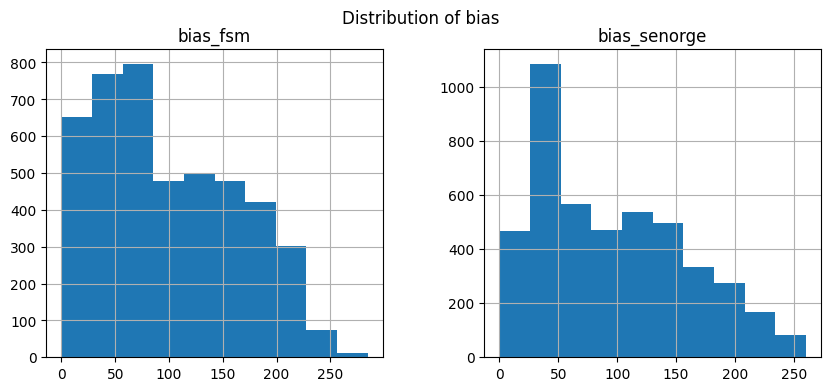

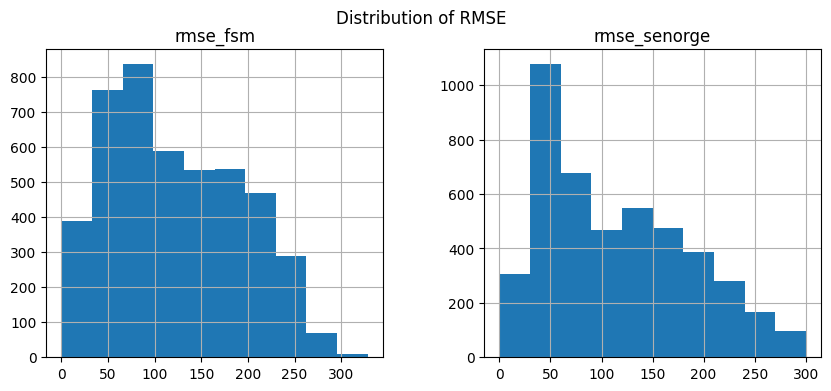

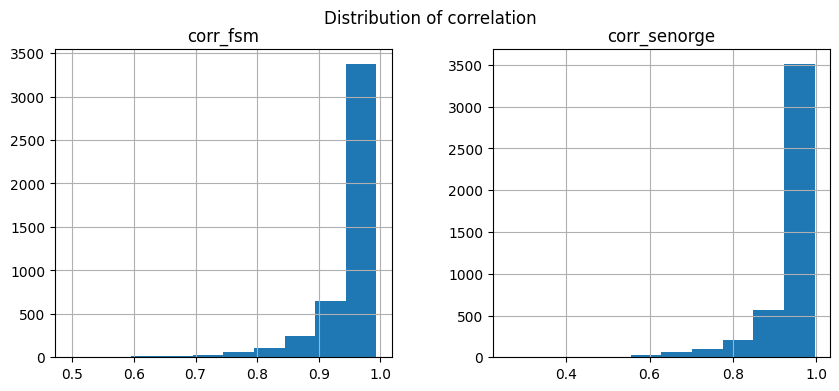

In [62]:
results_df[["bias_fsm", "bias_senorge"]].hist(figsize=(10, 4))
plt.suptitle("Distribution of bias")
plt.show()

results_df[["rmse_fsm", "rmse_senorge"]].hist(figsize=(10, 4))
plt.suptitle("Distribution of RMSE")
plt.show()

results_df[["corr_fsm", "corr_senorge"]].hist(figsize=(10, 4))
plt.suptitle("Distribution of correlation")
plt.show()

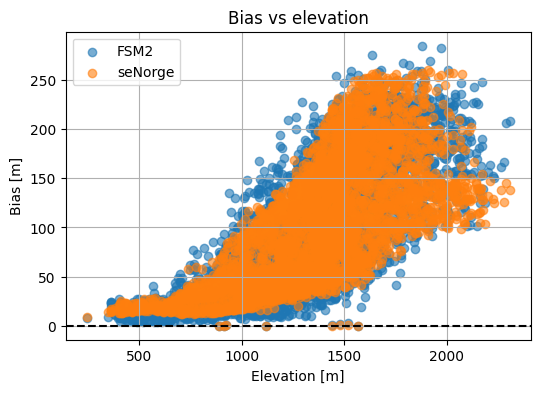

In [63]:
plt.figure(figsize=(6, 4))
plt.scatter(results_df["elev"], results_df["bias_fsm"], label="FSM2", alpha=0.6)
plt.scatter(results_df["elev"], results_df["bias_senorge"], label="seNorge", alpha=0.6)
plt.axhline(0, color="black", linestyle="--")
plt.xlabel("Elevation [m]")
plt.ylabel("Bias [m]")
plt.title("Bias vs elevation")
plt.legend()
plt.grid(True)
plt.show()

In [64]:
results_df.sort_values("elev")[["station", "elev"]].head(10)
results_df.sort_values("elev")[["station", "elev"]].tail(10)

,station,elev
2939,VIR3213A,2178.0
4311,VIR4598A,2188.0
3039,VIR3314A,2201.0
2651,VIR2921A,2213.0
2842,VIR3116A,2224.0
3036,VIR3311A,2229.0
2941,VIR3215A,2263.0
3607,VIR3888A,2277.0
3604,VIR3885A,2287.0
4104,VIR4389A,2306.0


In [65]:
print("SNOWPACK max:", float(snow_daily.max().values))
print("FSM2 max:", float(fsm_series.max().values))
print("seNorge max:", float(senorge_series.max().values))

SNOWPACK max: 0.06419833333333334
FSM2 max: 64.0
seNorge max: 54.400001525878906


In [66]:
print(results_df.columns)

Index(['station', 'elev', 'lon', 'lat', 'bias_fsm', 'rmse_fsm', 'corr_fsm',
       'bias_senorge', 'rmse_senorge', 'corr_senorge'],
      dtype='str')
